In [ ]:
# Conectar ao Google Drive
#from google.colab import drive
#drive.mount("/content/drive")

In [ ]:
# Importar alguns dos módulos necessários
import os
#import zipfile
import cv2
from PIL import Image
import numpy as np
import math
import matplotlib.pyplot as plt

# Dataset

In [ ]:
main = r'F:\Dataset\CNN'
equalize_falciparum_path = r'F:\Dataset\CNN\Falciparum equalized\Parasitized'
equalize_white_path = r'F:\Dataset\CNN\Falciparum equalized\WhiteBloodCells'

In [ ]:
falciparum_names = [os.path.join(equalize_falciparum_path,f) for f in os.listdir(equalize_falciparum_path)]
white_names = [os.path.join(equalize_white_path,f) for f in os.listdir(equalize_white_path)]

In [ ]:
falciparum_qtd = len(falciparum_names)
white_qtd = len(white_names)
print(f'falciparum_qtd: {falciparum_qtd}\nwhite_names: {white_qtd}')

falciparum_qtd: 52639
white_names: 20131


In [ ]:
def Dividir_data (valor_total):
  para_treino = 70
  para_teste = 20
  para_validacao = 10

  para_treinor = math.floor(valor_total * (para_treino / 100))
  para_tester = math.floor(valor_total * (para_teste / 100))
  para_validacaor = math.floor(valor_total * (para_validacao / 100))

  #para_treinor = valor_total * (para_treino / 100) - para_treinor
  #para_tester = valor_total * (para_teste / 100) - para_tester
  #para_validacaor = valor_total * (para_validacao / 100) - para_validacaor

  print(f"{para_treino}% de {valor_total} é {para_treinor:.0f}")
  print(f"{para_teste}% de {valor_total} é {para_tester:.0f}")
  print(f"{para_validacao}% de {valor_total} é {para_validacaor:.0f}")

In [ ]:
print ('\nFalciparum')
Dividir_data(falciparum_qtd)
print ('\nWhiteCell')
Dividir_data(white_qtd)


Falciparum
70% de 52639 é 36847
20% de 52639 é 10527
10% de 52639 é 5263

WhiteCell
70% de 20131 é 14091
20% de 20131 é 4026
10% de 20131 é 2013


In [ ]:
falciparum_names_train = falciparum_names[:14091]
white_names_train = white_names[:14091]

In [ ]:
def mostrar(imagem,title):
  fig = plt.gcf()
  fig.set_size_inches(20,10)
  plt.imshow(imagem, cmap='gray')
  plt.title(title)
  plt.axis('off')
  plt.show()

In [ ]:
r =np.random.randint(0,len(falciparum_names_train))
r

5295

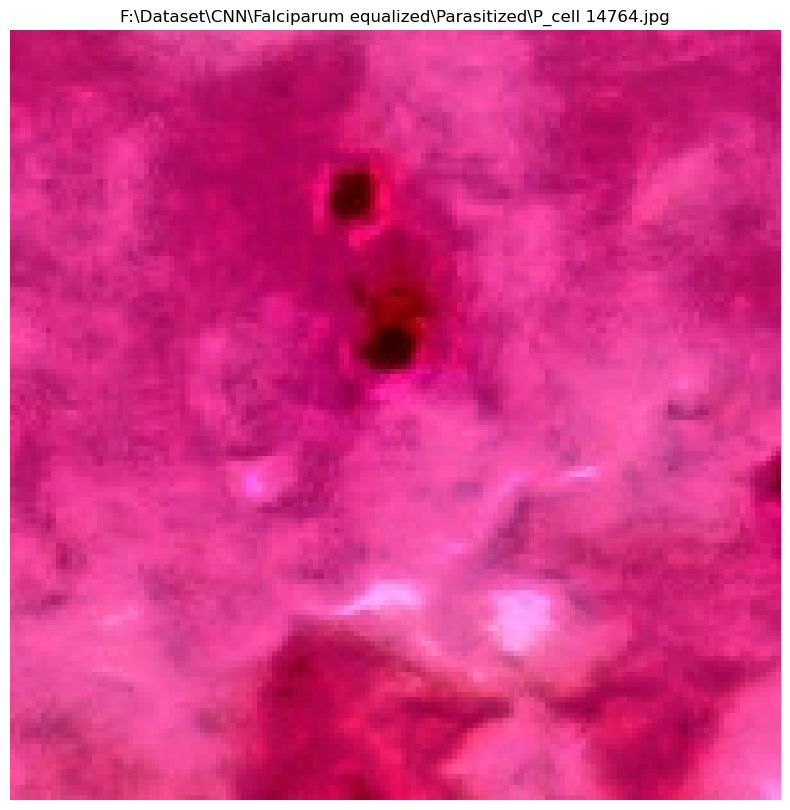

In [ ]:
mostrar(cv2.imread(falciparum_names_train[r]),falciparum_names_train[r]);

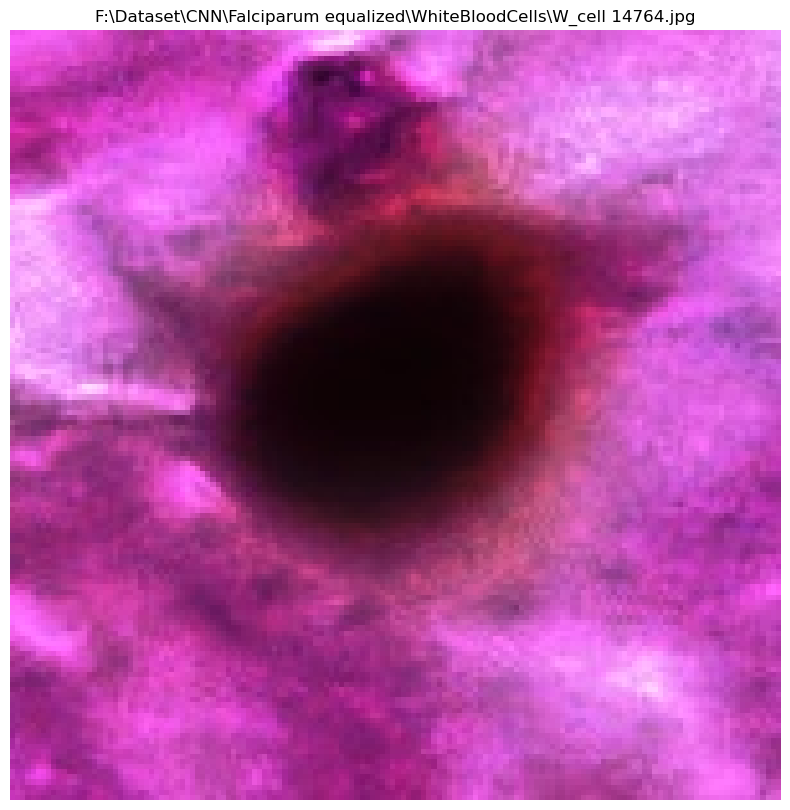

In [ ]:
mostrar(cv2.imread(white_names_train[r]),white_names_train[r]);

# Data

In [ ]:
np.random.seed(123)
data = []
labels = []
print(data,labels)
# Separa as imagens, a adiciona mais rodando as imagens.

# for i in vivax_names_train:
#     try:

#         image = cv2.imread(i)
#         image_array = Image.fromarray(image , 'RGB')
#         resize_img = image_array.resize((50 , 50))
#         #rotated45 = resize_img.rotate(45) #Rotaciona
#         #rotated75 = resize_img.rotate(75) #Rotaciona
#         #blur = cv2.blur(np.array(resize_img) ,(10,10))
#         data.append(np.array(resize_img))
#         #data.append(np.array(rotated45))
#         #data.append(np.array(rotated75))
#         #data.append(np.array(blur))
#         labels.append(0)
#         #labels.append(1)
#         #labels.append(1)
#         #labels.append(1)

#     except AttributeError:
#         print('error')

for u in falciparum_names_train:
    try:

        image = cv2.imread(u)
        image_array = Image.fromarray(image , 'RGB')
        resize_img = image_array.resize((50 , 50))
        #rotated45 = resize_img.rotate(45) #Rotaciona
        #rotated75 = resize_img.rotate(75) #Rotaciona
        data.append(np.array(resize_img))
        #data.append(np.array(rotated45))
        #data.append(np.array(rotated75))
        labels.append(1)
        #labels.append(0)
        #labels.append(0)

    except AttributeError:
        print('error')

for o in white_names_train:
    try:

        image = cv2.imread(o)
        image_array = Image.fromarray(image , 'RGB')
        resize_img = image_array.resize((50 , 50))
        #rotated45 = resize_img.rotate(45) #Rotaciona
        #rotated75 = resize_img.rotate(75) #Rotaciona
        data.append(np.array(resize_img))
        #data.append(np.array(rotated45))
        #data.append(np.array(rotated75))
        labels.append(0)
        #labels.append(0)
        #labels.append(0)

    except AttributeError:
        print('error')

[] []


In [ ]:
cells = np.array(data) #Conjunto das imagens
labels = np.array(labels) #Labels

np.save('Cells' , cells)
np.save('Labels' , labels)

In [ ]:
type(labels)

numpy.ndarray

In [ ]:
print(f'Cells : {cells.shape} | labels : {labels.shape}')

Cells : (28182, 50, 50, 3) | labels : (28182,)


In [ ]:
qtd=7 #Quantidade de imagens para plot

# Plotagem 1

In [ ]:
cells.shape[0]

28182

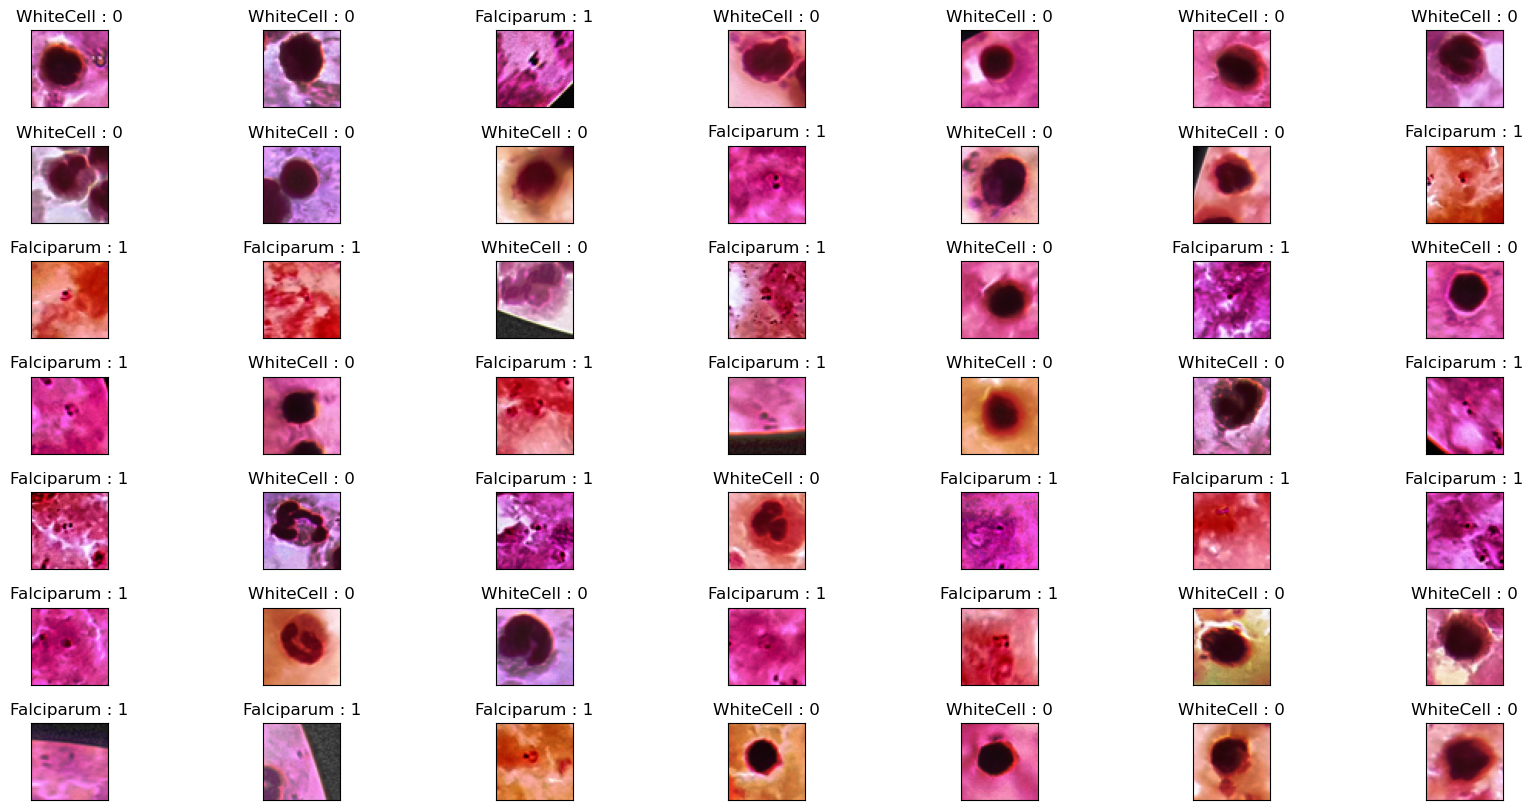

In [ ]:
plt.figure(1 , figsize = (20 , 10))
n = 0
for i in range(qtd*qtd):
    n += 1
    r = np.random.randint(0 , cells.shape[0] , 3)
    plt.subplot(qtd , qtd , n)
    plt.subplots_adjust(hspace = 0.5 , wspace = 0.5)
    plt.imshow(cells[r[0]])
    if labels[r[0]] == 10:
      label_text = 'Vivax'
    elif labels[r[0]] == 1:
      label_text = 'Falciparum'
    else:
      label_text = 'WhiteCell'
    plt.title(f"{label_text} : {labels[r[0]]}")  # Use f-string for formatted title
    #plt.title('{} : {}'.format('Infected' if labels[r[0]] == 1 else 'Unifected' , labels[r[0]]) )
    plt.xticks([]) , plt.yticks([])

plt.show()

# Plotagem 2

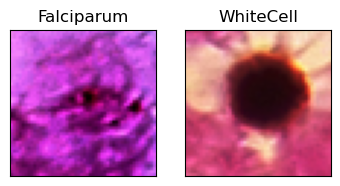

In [ ]:
# plt.figure(1, figsize = (15 , 7))
# plt.subplot(1 , 3 , 1)
# plt.imshow(cells[0])
# plt.title('Vivax')
# plt.xticks([]) , plt.yticks([])

plt.subplot(1 , 3 , 2)
plt.imshow(cells[10000])
plt.title('Falciparum')
plt.xticks([]) , plt.yticks([])

plt.subplot(1 , 3 , 3)
plt.imshow(cells[20000])#5000
plt.title('WhiteCell')
plt.xticks([]) , plt.yticks([])

plt.show()

# Formatação de Imagens

In [ ]:
# formata as imagens para um novo formato
n = np.arange(cells.shape[0])
print(n)
np.random.shuffle(n)

[    0     1     2 ... 28179 28180 28181]


In [ ]:
cells = cells[n]
labels = labels[n]
cells = cells.astype(np.float32)
labels = labels.astype(np.int32)
cells = cells/255

In [ ]:
labels

array([0, 0, 0, ..., 0, 1, 0])

# Adiciona mais Bibliotecas

In [ ]:
# Proximas bibliotecas a serem usadas.
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import (Conv2D,MaxPooling2D,Flatten,Dense,Dropout,)
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
import time

# Separando dados para Teste e Treino

In [ ]:
x_train , x , y_train , y = train_test_split(cells , labels , test_size = 0.2 , random_state = 43)
x_eval , x_test , y_eval , y_test = train_test_split(x , y , test_size = 0.5 , random_state = 43)
y_train = to_categorical(y_train, num_classes=2) # num_classes=2
y_test = to_categorical(y_test, num_classes=2)

In [ ]:
print(f'train data shape {x_train.shape} ,eval data shape {x_eval.shape} , test data shape {x_test.shape}')

train data shape (22545, 50, 50, 3) ,eval data shape (2818, 50, 50, 3) , test data shape (2819, 50, 50, 3)


# Definição do modelo CNN

In [ ]:
# Definindo o modelo da CNN
model = tf.keras.Sequential()
model.add(Conv2D(128, kernel_size=(7, 7), activation="relu", input_shape=(50 , 50 ,3)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(32, kernel_size=(3, 3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(2, activation="softmax"))

# Treino

In [ ]:
!nvidia-smi

Tue May 28 09:24:00 2024       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 551.23                 Driver Version: 551.23         CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                     TCC/WDDM  | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   47C    P0              9W /   50W |    1836MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Compilando o modelo
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
st = time.time()

# Treinamento do modelo
model.fit(x_train, y_train, epochs=100, batch_size=100, validation_split=0.2)
et = time.time()
tempo_decorrido = et - st

Epoch 1/100
181/181 [==============================] - 10s 29ms/step - loss: 0.1019 - accuracy: 0.9625 - val_loss: 0.0516 - val_accuracy: 0.9807
Epoch 2/100
181/181 [==============================] - 5s 27ms/step - loss: 0.0415 - accuracy: 0.9872 - val_loss: 0.0454 - val_accuracy: 0.9849
Epoch 3/100
181/181 [==============================] - 5s 26ms/step - loss: 0.0303 - accuracy: 0.9904 - val_loss: 0.0258 - val_accuracy: 0.9922
Epoch 4/100
181/181 [==============================] - 5s 27ms/step - loss: 0.0212 - accuracy: 0.9936 - val_loss: 0.0176 - val_accuracy: 0.9949
Epoch 5/100
181/181 [==============================] - 5s 27ms/step - loss: 0.0188 - accuracy: 0.9941 - val_loss: 0.0178 - val_accuracy: 0.9947
Epoch 6/100
181/181 [==============================] - 5s 26ms/step - loss: 0.0147 - accuracy: 0.9950 - val_loss: 0.0138 - val_accuracy: 0.9953
Epoch 7/100
181/181 [==============================] - 5s 27ms/step - loss: 0.0137 - accuracy: 0.9955 - val_loss: 0.0160 - val_accuracy

# Avaliação do Modelo

In [ ]:
# Avaliando o Modelo:
loss, acc = model.evaluate(x_test, y_test, verbose = 0);

print(f'Acurácia (%):  {(acc*100):.2f}')
print(f"Loss: {loss:.2f}")
print (f'Tempo decorrido: {tempo_decorrido:.2f}')

Acurácia (%):  99.82
Loss: 0.01
Tempo decorrido: 478.76


# Inicio Tunnel

In [ ]:
# Instalação das dependências necessárias
!pip install -q tensorflow-addons

# Importe de bibliotecas necessárias
import tensorflow as tf
import tensorflow_addons as tfa
from tensorflow.keras import layers, models

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 12.9 MB/s eta 0:00:00


/usr/local/lib/python3.10/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


In [ ]:
def create_vit_model(input_shape=(50, 50, 3), num_classes=3):
    vit_model = tf.keras.applications.VGG16(
        include_top=False, input_shape=input_shape, weights='imagenet'
    )

    # Congela as camadas do ViT
    vit_model.trainable = False

    # Adapta as dimensões da saída do ViT para a entrada de uma camada Dense
    global_average_layer = layers.GlobalAveragePooling2D()
    dense_layer_1 = layers.Dense(128, activation='relu')
    dense_layer_2 = layers.Dense(64, activation='relu')
    dense_layer_3 = layers.Dense(32, activation='relu')
    dropout_layer = layers.Dropout(0.2)
    output_layer = layers.Dense(num_classes, activation='softmax')

    # Cria o modelo
    model = models.Sequential([
        vit_model,
        global_average_layer,
        dense_layer_1,
        dense_layer_2,
        dense_layer_3,
        dropout_layer,
        output_layer
    ])

    return model


In [ ]:
# Cria e compilar o modelo ViT
vit_model = create_vit_model()
vit_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

58889256/58889256 [==============================] - 3s 0us/step


In [ ]:
# Treina o modelo
stVit = time.time()
vit_model.fit(x_train, y_train, epochs=10, batch_size=100, validation_split=0.2)
etVit = time.time()
tempo_decorridoVit = etVit - stVit

Epoch 1/10
618/618 [==============================] - 39s 53ms/step - loss: 0.2982 - accuracy: 0.8773 - val_loss: 0.2487 - val_accuracy: 0.8928
Epoch 2/10
618/618 [==============================] - 25s 40ms/step - loss: 0.2335 - accuracy: 0.9065 - val_loss: 0.2137 - val_accuracy: 0.9116
Epoch 3/10
618/618 [==============================] - 24s 38ms/step - loss: 0.2185 - accuracy: 0.9117 - val_loss: 0.2040 - val_accuracy: 0.9136
Epoch 4/10
618/618 [==============================] - 25s 40ms/step - loss: 0.2094 - accuracy: 0.9158 - val_loss: 0.2170 - val_accuracy: 0.9035
Epoch 5/10
618/618 [==============================] - 24s 39ms/step - loss: 0.2015 - accuracy: 0.9188 - val_loss: 0.2195 - val_accuracy: 0.9075
Epoch 6/10
618/618 [==============================] - 25s 40ms/step - loss: 0.1981 - accuracy: 0.9208 - val_loss: 0.2166 - val_accuracy: 0.9044
Epoch 7/10
618/618 [==============================] - 25s 41ms/step - loss: 0.1918 - accuracy: 0.9236 - val_loss: 0.2001 - val_accuracy:

In [ ]:
# Avalia o modelo
lossVit, accVit = vit_model.evaluate(x_test, y_test, verbose=0)
print(f'Acurácia (%):  {(acc*100):.2f}')
print(f"Loss: {loss:.2f}")
print (f'Tempo decorrido: {tempo_decorridoVit:.2f}')

Acurácia (%):  96.21
Loss: 0.11
Tempo decorrido: 269.84


# Matriz de Confusão

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# Faz predições no conjunto de teste
y_pred = model.predict(x_test)
y_pred_class = np.argmax(y_pred, axis=1)

# Converte rótulos para classes binárias
y_test_binary = np.argmax(y_test, axis=1)

# Calcula a matriz de confusão
conf_matrix = confusion_matrix(y_test_binary, y_pred_class)

89/89 [==============================] - 0s 3ms/step


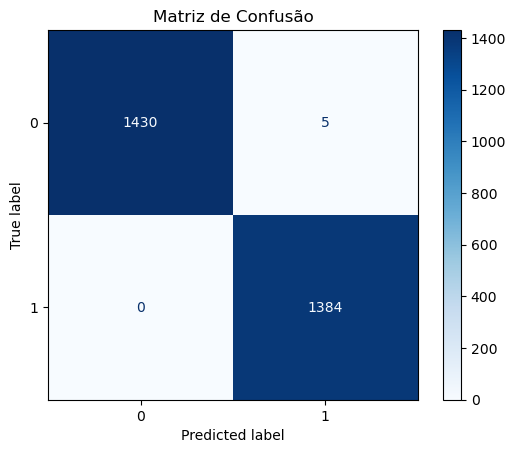

In [ ]:
# Plotar a matriz de confusão
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusão')
plt.show()

# Precisão

In [ ]:
from sklearn.metrics import precision_score

In [ ]:
# Calcular a precisão
precision = precision_score(y_test_binary, y_pred_class)

print(f'Precisão: {(precision*100):.2f}')

Precisão: 99.64


# Visualização da Previsão

In [ ]:
#import numpy as np
from random import randint

89/89 [==============================] - 1s 6ms/step


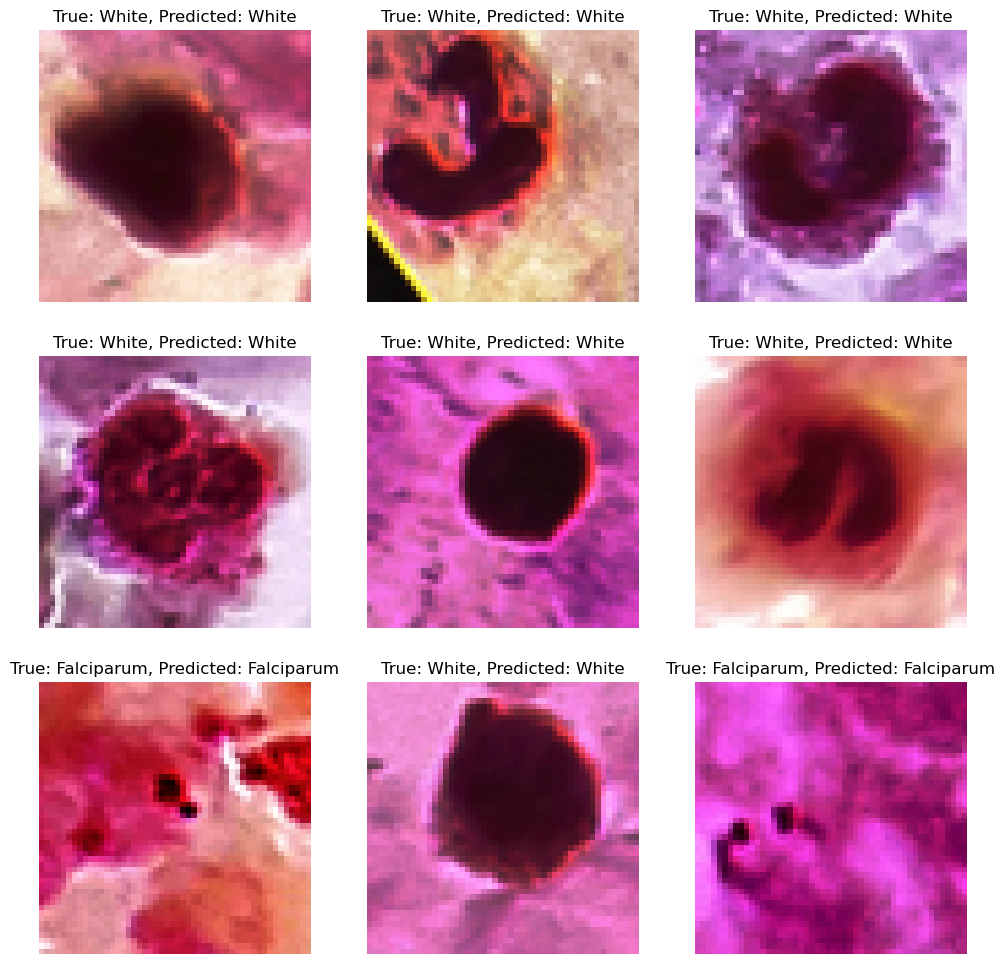

In [ ]:
# Faz previsões no conjunto de teste
predictions = model.predict(x_test)

# Converter as previsões em classes
predicted_classes = np.argmax(predictions, axis=1)

# Visualizar algumas imagens de teste com suas previsões
num_rows = 3
num_cols = 3
plt.figure(figsize=(12, 12))

for i in range(num_rows * num_cols):
    index = randint(0, len(x_test) - 1)
    img = x_test[index]
    true_label = y_test_binary[index]
    predicted_label = predicted_classes[index]

    if true_label==0:
      true_label="White"
    else:
      true_label="Falciparum"

    if predicted_label==0:
      predicted_label="White"
    else:
      predicted_label="Falciparum"

    plt.subplot(num_rows, num_cols, i + 1)
    plt.imshow(img)
    plt.title(f'True: {true_label}, Predicted: {predicted_label}')
    plt.axis('off')

plt.show()